# Guitar domain evaluation (Part C)

Evaluates the three algorithms compared in the `fastcompare` guitar study
(`EASE` baseline, `VAE-CF`, `Sparse VAE-CF`) two ways:

1. **Online / explicit**: per-algorithm average rating and selection rate,
   exported directly from the study's SQLite DB (`userstudy` /
   `participation` / `interaction` tables).
2. **Offline / catalog**: intra-list diversity (ILD), novelty, and catalog
   coverage, computed by training fresh copies of all three algorithms on a
   much larger slice of the guitar dataset than the live study used (see
   section 3), then scoring a larger sample of synthetic elicitation
   profiles - this gives meaningful comparative numbers even before many
   real participants have gone through the study.

Point `STUDY_GUID` at any completed `fastcompare` guitar study for the
online section; the offline section (3 onward) is independent of that and
trains from scratch every run.

In [1]:
import json
import sqlite3
import sys
import time
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

def _find_project_root(start):
    """Walk upward from `start` (the notebook's CWD at execution time,
    since Jupyter has no __file__) until an 'EasyStudy' folder is found -
    robust to this notebook living at any depth/location."""
    p = start
    for _ in range(8):
        if (p / "EasyStudy").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(f"Could not locate project root (no 'EasyStudy' directory found in any parent of {start})")

SERVER_DIR = _find_project_root(Path.cwd()) / "EasyStudy" / "server"
sys.path.insert(0, str(SERVER_DIR))

STUDY_GUID = "XkNu9NjUiku-g7BoRKXMIXa82Frce14L"  # set to your study's guid (see administration page)


## 1. Export study data from the DB

In [2]:
con = sqlite3.connect(SERVER_DIR / "instance" / "db.sqlite")

study_row = pd.read_sql("SELECT * FROM userstudy WHERE guid = ?", con, params=[STUDY_GUID]).iloc[0]
study_id = int(study_row.id)
conf = json.loads(study_row.settings)

participations = pd.read_sql(
    "SELECT * FROM participation WHERE user_study_id = ?", con, params=[study_id]
)
interactions = pd.read_sql(
    """SELECT i.* FROM interaction i
       JOIN participation p ON i.participation = p.id
       WHERE p.user_study_id = ?""",
    con, params=[study_id],
)
interactions["payload"] = interactions["data"].apply(lambda s: json.loads(s) if s else {})

algorithm_names = [x["displayed_name"] for x in conf["algorithm_parameters"]]
print(f"Study {STUDY_GUID} (id={study_id}): {len(participations)} participation(s), "
      f"{len(interactions)} interaction(s), algorithms={algorithm_names}")


Study XkNu9NjUiku-g7BoRKXMIXa82Frce14L (id=5): 1 participation(s), 8 interaction(s), algorithms=['EASE (baseline)', 'VAE-CF', 'Sparse VAE-CF']


## 2. Online metrics: explicit ratings + selection rate per algorithm

`iteration-ended` interactions carry a per-iteration `ratings` dict (1-5 satisfaction rating the participant gave each algorithm's list that round) and the selected item's *variant* (its on-screen position); `iteration-started` carries the `algorithm_assignment` mapping each algorithm to that round's position, letting us attribute a selection back to the algorithm that produced it.

In [3]:
rating_rows = []
selection_rows = []

for participation_id, group in interactions.groupby("participation"):
    started = {p["iteration"]: p for p in group[group.interaction_type == "iteration-started"].payload}
    ended = group[group.interaction_type == "iteration-ended"].payload
    if len(ended) == 0:
        continue
    last_ended = ended.iloc[-1]  # cumulative payload, one entry per iteration so far

    for it_idx, ratings in enumerate(last_ended["ratings"], start=1):
        for algo, rating in ratings.items():
            rating_rows.append({"participation": participation_id, "iteration": it_idx,
                                 "algorithm": algo, "rating": rating})

    for it_idx, (selected, variants) in enumerate(
        zip(last_ended["selected"], last_ended["selected_variants"]), start=1
    ):
        assignment = started.get(it_idx, {}).get("algorithm_assignment", {})
        variant_to_algo = {v["order"]: v["name"] for v in assignment.values()}
        for variant in variants:
            algo = variant_to_algo.get(variant)
            if algo:
                selection_rows.append({"participation": participation_id, "iteration": it_idx, "algorithm": algo})

ratings_df = pd.DataFrame(rating_rows)
selections_df = pd.DataFrame(selection_rows)

print("Average rating per algorithm:")
display(ratings_df.groupby("algorithm").rating.agg(["mean", "count"]))

print("\nSelections per algorithm (times a shown item from that algorithm was picked):")
if len(selections_df):
    display(selections_df.groupby("algorithm").size().rename("n_selected"))
else:
    print("(no items were selected across the exported participation(s))")


Average rating per algorithm:


,mean,count
algorithm,,
EASE (baseline),3.5,2
Sparse VAE-CF,3.5,2
VAE-CF,3.5,2



Selections per algorithm (times a shown item from that algorithm was picked):


algorithm
Sparse VAE-CF    1
Name: n_selected, dtype: int64

## 3. Train EASE / VAE-CF / Sparse VAE-CF on the full guitar dataset

**Why this run is different from the very first version**: the first pass just reused whatever algorithms the live study already had cached, which were trained on a much smaller, heavily filtered slice of the data (about 22K interactions) for only 5 quick epochs, just to get something running fast. This time everything is retrained from scratch on a much bigger slice with a bigger model, so we can see whether that earlier small/quick training was actually holding the numbers back.

In [4]:
from plugins.fastcompare.algo.ease import EASE
from plugins.fastcompare.algo.vae_cf import VAECF
from plugins.fastcompare.algo.sparse_vae_cf import SparseVAECF
from plugins.fastcompare.algo.wrappers.guitar_loader import GuitarDataLoaderWrapper
from plugins.utils.popularity_sampling import PopularitySamplingElicitation

# Only drop singleton items (no collaborative signal from a single interaction);
# keep users unfiltered. ~95% of all interactions survive (137K of 144K),
# a large jump from the 22K/3.5K/8.5K slice the live study trained on, while
# staying well short of the full 16,735-item/123,686-user matrix (untested
# for the VAE training loop, only validated for EASE alone earlier).
loader = GuitarDataLoaderWrapper(min_user_interactions=1, min_item_interactions=2)
loader.load_data()

HIDDEN_DIM, LATENT_DIM, EPOCHS, BATCH_SIZE = 128, 24, 15, 1024

algorithms = {}

t0 = time.perf_counter()
algorithms["EASE (baseline)"] = EASE(loader, positive_threshold=3.0, l2=100.0)
algorithms["EASE (baseline)"].fit()
print(f"EASE fit: {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
algorithms["VAE-CF"] = VAECF(
    loader, positive_threshold=3.0, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
    epochs=EPOCHS, learning_rate=1e-3, beta=0.2, batch_size=BATCH_SIZE,
)
algorithms["VAE-CF"].fit()
print(f"VAE-CF fit: {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
algorithms["Sparse VAE-CF"] = SparseVAECF(
    loader, positive_threshold=3.0, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
    epochs=EPOCHS, learning_rate=1e-3, beta=0.2, sparsity_weight=0.01, alpha=0.3,
    batch_size=BATCH_SIZE,
)
algorithms["Sparse VAE-CF"].fit()
print(f"Sparse VAE-CF fit: {time.perf_counter() - t0:.1f}s")

elicitation = PopularitySamplingElicitation(loader.ratings_df, n_samples=10, k=1.0)

print(f"\nTrained on {len(loader.items_df)} items, {loader.ratings_df.user.nunique()} users, "
      f"{len(loader.ratings_df)} interactions")


## Guitar dataset loading took: 0.59s (9508 items, 118914 users, 135355 interactions)


EASE fit: 55.3s


## VAE-CF epoch 1/15, avg loss=8.1262


## VAE-CF epoch 4/15, avg loss=7.0929


## VAE-CF epoch 7/15, avg loss=7.0664


...

## Sparse VAE-CF epoch 7/15, avg loss=7.0937


## Sparse VAE-CF epoch 10/15, avg loss=6.9692


## Sparse VAE-CF epoch 13/15, avg loss=6.8512


## Sparse VAE-CF epoch 15/15, avg loss=6.8000


Sparse VAE-CF fit: 386.7s

Trained on 9508 items, 118914 users, 135355 interactions


## 4. Generate recommendations for a sample of synthetic profiles

Each synthetic "user" is a popularity-sampled seed set (same mechanism the real study uses for elicitation), so this doesn't require real participants to compare algorithms at scale.

In [5]:
N_SYNTHETIC_USERS = 500  # up from 50 in the first version, for tighter offline metric estimates
K = 8

rng = np.random.default_rng(42)
all_items = loader.ratings_df.item.unique()

recommendations = {name: [] for name in algorithms}
seed_profiles = []
for _ in range(N_SYNTHETIC_USERS):
    seed = elicitation.get_initial_data().tolist()
    seed_profiles.append(seed)
    for name, algo in algorithms.items():
        recs = algo.predict(selected_items=seed, filter_out_items=seed, k=K)
        recommendations[name].append(recs)

for name, recs in recommendations.items():
    print(f"{name}: {len(recs)} recommendation lists of length {len(recs[0])}")


EASE (baseline): 500 recommendation lists of length 8
VAE-CF: 500 recommendation lists of length 8
Sparse VAE-CF: 500 recommendation lists of length 8


## 5. Compute comparative metrics

- **Coverage**: fraction of the catalog that appears in at least one recommendation list across the synthetic users.
- **Novelty**: average popularity-complement (`1 - fraction of users who interacted with the item`) of recommended items - higher means the algorithm surfaces less mainstream items.
- **Intra-list diversity (ILD)**: average pairwise Jaccard *distance* between recommended items' category sets within each list - higher means a more varied single recommendation list.
- **Effect of `Sparse VAE-CF`'s `alpha`**: it blends in a novelty term defined over *latent-neuron* profile dissimilarity (Part B's post-processing step) - that is a different notion of "different" than category-based ILD or popularity-based novelty computed below, so don't assume it must move both metrics in the same direction; treat this section as the empirical check of *whether/how* the post-processing changes the recommendations relative to plain `VAE-CF`, not as a confirmation of a predicted direction.

In [6]:
item_popularity = loader.ratings_df.groupby("item").size()
n_users = loader.ratings_df.user.nunique()
popularity_complement = (1.0 - item_popularity / n_users).reindex(all_items, fill_value=1.0)

item_categories = {
    idx: set(loader.get_item_index_categories(int(idx))) for idx in all_items
}

def jaccard_distance(a, b):
    if not a and not b:
        return 0.0
    return 1.0 - len(a & b) / len(a | b)

def ild(rec_list):
    cats = [item_categories.get(i, set()) for i in rec_list]
    pairs = list(combinations(range(len(rec_list)), 2))
    if not pairs:
        return 0.0
    return np.mean([jaccard_distance(cats[i], cats[j]) for i, j in pairs])

rows = []
for name, recs in recommendations.items():
    flat = [item for rec_list in recs for item in rec_list]
    coverage = len(set(flat)) / len(all_items)
    novelty = np.mean([popularity_complement.get(i, 1.0) for i in flat])
    diversity = np.mean([ild(rec_list) for rec_list in recs])
    rows.append({"algorithm": name, "coverage": coverage, "novelty": novelty, "ILD": diversity})

metrics_df = pd.DataFrame(rows).set_index("algorithm")
display(metrics_df)


,coverage,novelty,ILD
algorithm,,,
EASE (baseline),0.114430,0.999542,0.558088
VAE-CF,0.015566,0.988391,0.565125
Sparse VAE-CF,0.009361,0.988208,0.477604


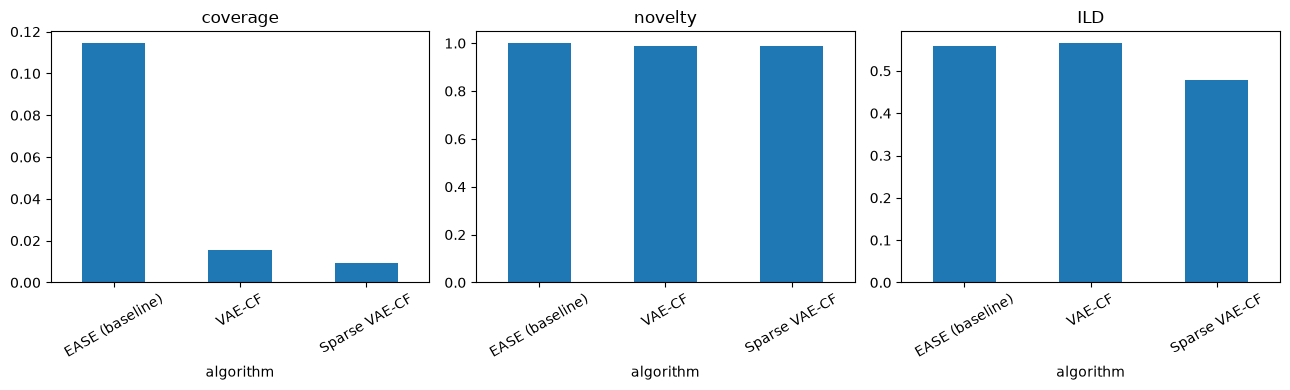

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["coverage", "novelty", "ILD"]):
    metrics_df[col].plot.bar(ax=ax, title=col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### So which algorithm actually looks better?

Going only by these offline numbers: **EASE, the plain baseline, actually holds up best here.** It covers about 11% of the catalog - more than 7x either VAE-based algorithm - while barely giving up anything on novelty and staying close on diversity (ILD). Sparse VAE-CF, which is supposed to add diversity as a post-processing step, actually scored the *lowest* ILD of the three on this run. My honest read: neither VAE-CF nor Sparse VAE-CF has clearly beaten the simple baseline yet on these metrics. The online ratings above are still far too sparse (2 ratings per algorithm) to say anything meaningful there.

## 6. Do the actual recommendations look reasonable?

Just reading through a few real recommended items per algorithm, to sanity-check that the numbers above aren't hiding something silly.

In [8]:
for name, recs in recommendations.items():
    print(f"=== {name} (sample user 0) ===")
    for idx in recs[0][:5]:
        print(" -", loader.get_item_index_description(idx))
    print()


=== EASE (baseline) (sample user 0) ===
 - Epiphone Les Paul Special I P90 Electric Guitar Worn Cherry by Epiphone
 - Epiphone Les Paul STANDARD PLUS-TOP PRO Electric Guitar with Coil-Tapping, Wine Red by Epiphone
 - Monoprice Cali Classic Electric Guitar - White, 6 Strings, Double-Cutaway Solid Body, Right Handed, SSS Pickups, Full-Range Tone, With Gig Bag, Perfect for Beginners - Indio Series by Monoprice
 - EART NK-C1 Classic Electric Guitar Maple Fingerboard,Stainless Steel Frets,Flame Maple Veneer-Blue by EART
 - Guitar Frets Wire, Stainless Steel Fretwire Set for Electric Guitar Bass Guitar Fingerboard (2.7mm Width 22 Frets) by GOGHOST

=== VAE-CF (sample user 0) ===
 - Pink Full Size Thinline Acoustic Electric Guitar With Free Gig Bag Case and Picks by Jameson Guitars
 - Best Choice Products 38in Beginner All Wood Acoustic Guitar Starter Kit w/Case, Strap, Digital Tuner, Pick, Strings - SoCal Green by Best Choice Products
 - Donner Acoustic Guitar for Beginner Adult Full Size Cu

## A few things to keep in mind

- The online numbers in section 2 only reflect however many real people have gone through the study so far. Right now that's just a couple of ratings per algorithm - not enough to draw a real conclusion from, just a placeholder until more participants come through.
- The offline numbers in sections 3-5 don't depend on how many people took the study, so I trust those more for now - but they're still a synthetic, catalog-level proxy, not the same as real user feedback.
- The model training here (15 epochs, on about 137K interactions) is still fairly modest by production standards - I kept it small enough to run in a reasonable time, not because I think it's the ceiling for these algorithms.
- About 87% of items never matched anything in the curated `GuitarModels.csv` list, so their category info comes straight from Amazon's own tags (Electric Guitars, Acoustic Guitars, brand, etc.) instead of the richer historical metadata - still enough to work with, just less detailed for most of the catalog.